# Biomedical Image Pipeline — Stained Nuclei (Microscopy Images)

This notebook builds a small pipeline that:

```
raw image -> segmentation -> object measurements -> JSON record -> short text summary
```

It uses three things together: a local vision AI model (VLM) to describe an
image, classical image processing (Otsu + scikit-image) to measure objects,
and a U-Net model to segment the images.

**How to run this notebook**
1. Put `nuclei_dataset.zip` in the same folder as this notebook (or already
   unzipped as a `nuclei_dataset` folder).
2. Run the cells from top to bottom.
3. If you want real answers from the AI model, install Ollama and pull the
   models first (see the Task 1 section). If Ollama is not running, the
   notebook still works — it uses a simple backup text instead, and always
   tells you which one it used.

**Important:** this is for learning only. Nothing here is a real medical
diagnosis tool.

## Contents

- **Setup** — imports, fixed settings, get the dataset
- **Task 1** — load data, look at it (EDA), describe one image with a local AI model
- **Task 2** — classical segmentation (Otsu), measure objects, ask the AI to explain the numbers
- **Task 3** — train a small U-Net, compare it against Otsu
- **Task 4** — full pipeline on the test images, saved as one CSV
- **Extra credit** — robustness check (blurred / low-contrast image)
- **Summary** — all the key numbers for the report, saved as one JSON file

Every section below has short, plain-English comments above each function,
explaining what it does and why.

---
## Setup

This cell does three simple jobs:
1. Import the libraries we need.
2. Set some fixed values (image size, file paths, random seed).
3. Get the dataset ready — unzip it if needed, or download it if it is
   missing completely.

There is no separate code package to import — every function used later is
defined directly in this notebook, so there is nothing that can go missing.

In [19]:
# Basic imports
import json, time, zipfile, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Fixed settings used everywhere in this notebook
IMG_SIZE = 256      # every image is resized to 256x256
TRAIN_CROP = 128     # size of the random crop used to train the U-Net
SEED = 0             # fixed seed so results do not change between runs

np.random.seed(SEED)

# Folders: dataset in, figures out, results out
DATA_DIR = Path("nuclei_dataset")
FIGS_DIR = Path("figs")
OUT_DIR = Path("out")
FIGS_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# If the dataset folder is missing, look for a zip file and unzip it.
# The zip's path inside is nuclei_dataset.zip -> nuclei_dataset -> files,
# so we always unzip into the current folder (not into a folder we make
# ourselves called nuclei_dataset).
if not (DATA_DIR / "metadata.csv").exists():
    zip_path = Path("nuclei_dataset.zip")
    if zip_path.exists():
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(".")
        print("Unzipped nuclei_dataset.zip")
    else:
        # No dataset and no zip here (e.g. a fresh Colab session) -
        # download it from the assignment's GitHub repo instead.
        print("No dataset zip found here - downloading it from GitHub...")
        os.system("git clone --depth 1 https://github.com/Nickolay-K/Assingnment-3-dataset dataset_repo")
        cloned_zip = Path("dataset_repo/nuclei_dataset.zip")
        if cloned_zip.exists():
            with zipfile.ZipFile(cloned_zip) as z:
                z.extractall("dataset_repo")
            print("Downloaded and unzipped the dataset.")

# The dataset might now be one folder deeper than expected - for example
# dataset_repo/nuclei_dataset (from the download above), or
# nuclei_dataset/nuclei_dataset (from unzipping by hand into a folder you
# already named nuclei_dataset). This searches for it and fixes DATA_DIR.
if not (DATA_DIR / "metadata.csv").exists():
    hits = list(Path(".").rglob("metadata.csv"))
    if hits:
        DATA_DIR = hits[0].parent
        print("Found the dataset at:", DATA_DIR)

assert (DATA_DIR / "metadata.csv").exists(), (
    "Cannot find the dataset. Put nuclei_dataset.zip in the same folder as "
    "this notebook and re-run this cell, or check your internet connection "
    "(this cell tries to download it automatically if it's missing)."
)
print("Dataset folder ready:", DATA_DIR.resolve())


No dataset zip found here - downloading it from GitHub...
Downloaded and unzipped the dataset.
Found the dataset at: dataset_repo/nuclei_dataset
Dataset folder ready: /content/dataset_repo/nuclei_dataset


---
## Task 1 — Load the data, look at it, and describe it with a local AI model

### 1.1 Load images, check the dataset, make grayscale copies

In [2]:
# This turns one image into a single grayscale array of numbers between 0 and 1.
# We resize every image to the same size so the model always gets the same shape.
def load_gray(path, size=IMG_SIZE):
    img = Image.open(path).convert("L")          # "L" = one grey channel
    if img.size != (size, size):
        img = img.resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0


# This does the same thing for a ground-truth mask, but keeps it as 0/1 values
# (no blending of pixel values, so we use "nearest" resizing instead of bilinear).
def load_mask(path, size=IMG_SIZE):
    img = Image.open(path).convert("L")
    if img.size != (size, size):
        img = img.resize((size, size), Image.NEAREST)
    return (np.asarray(img) > 127).astype(np.float32)


# Gives the list of image names (without the .png ending) inside one split folder.
def list_ids(split):
    return sorted(p.stem for p in (DATA_DIR / split / "images").glob("*.png"))


# Loads every image and mask in one split (train / val / test) into two big arrays.
def load_split(split, size=IMG_SIZE):
    ids = list_ids(split)
    images = np.stack([load_gray(DATA_DIR / split / "images" / f"{i}.png", size) for i in ids])
    masks = np.stack([load_mask(DATA_DIR / split / "masks" / f"{i}.png", size) for i in ids])
    return ids, images, masks


# Quick check: count how many PNG files are in each folder, so we notice early
# if something did not unzip properly.
for sub in ["train/images", "train/masks", "val/images", "val/masks",
            "test/images", "test/masks", "test_corrupted/images"]:
    folder = DATA_DIR / sub
    n = len(list(folder.glob("*.png"))) if folder.exists() else 0
    print(f"{sub:26s} {n:4d} files")

# metadata.csv has the "true answer" for each image: how many nuclei it has,
# and which density group it belongs to (sparse / normal / dense / clustered).
meta = pd.read_csv(DATA_DIR / "metadata.csv")
meta.columns = [c.strip() for c in meta.columns]
print("\nImages per split and density group:")
print(meta.groupby(["split", "density"]).size())
print(f"\nObjects per image: {meta.n_objects.min()} to {meta.n_objects.max()} "
      f"(average {meta.n_objects.mean():.1f})")


train/images                 80 files
train/masks                  80 files
val/images                   20 files
val/masks                    20 files
test/images                  12 files
test/masks                   12 files
test_corrupted/images         4 files

Images per split and density group:
split  density  
test   clustered     2
       dense         2
       normal        6
       sparse        2
train  clustered    13
       dense        13
       normal       40
       sparse       14
val    clustered     3
       dense         3
       normal       10
       sparse        4
dtype: int64

Objects per image: 5 to 85 (average 32.4)


### 1.2 Look at some sample images (one per density group)

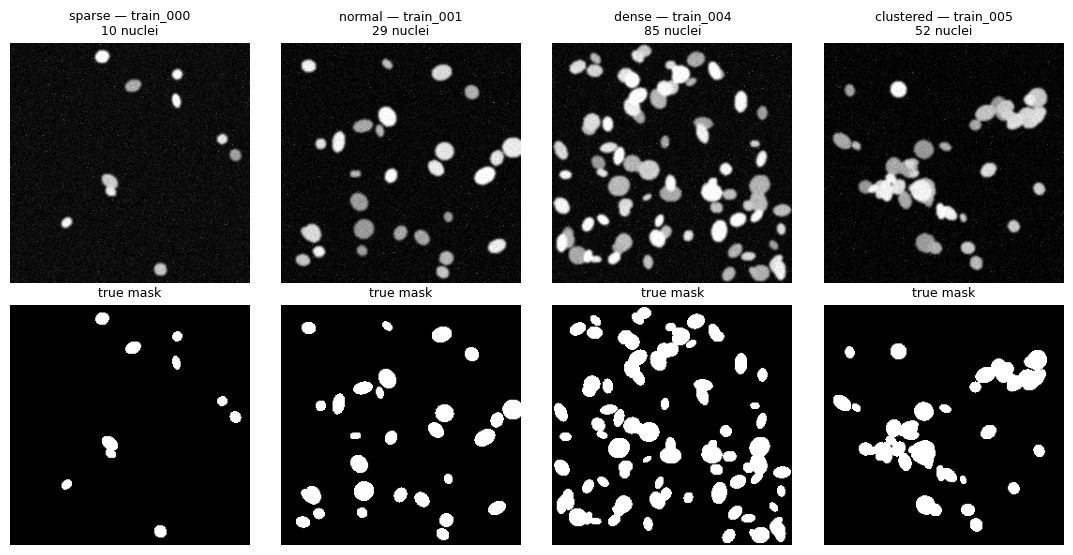

In [3]:
# Pick one training image from each density group, so we can see the range
# of difficulty in the dataset (few nuclei vs many, touching nuclei, etc).
reps = {}
for density in ["sparse", "normal", "dense", "clustered"]:
    rows = meta[(meta.split == "train") & (meta.density == density)]
    if len(rows):
        reps[density] = rows.iloc[0].image_id

fig, axes = plt.subplots(2, len(reps), figsize=(11, 5.6))
for j, (density, image_id) in enumerate(reps.items()):
    gray = load_gray(DATA_DIR / "train" / "images" / f"{image_id}.png")
    mask = load_mask(DATA_DIR / "train" / "masks" / f"{image_id}.png")
    n_obj = int(meta.loc[meta.image_id == image_id, "n_objects"].iloc[0])

    axes[0, j].imshow(gray, cmap="gray", vmin=0, vmax=float(np.percentile(gray, 99.9)))
    axes[0, j].set_title(f"{density} — {image_id}\n{n_obj} nuclei", fontsize=9)
    axes[1, j].imshow(mask, cmap="gray")
    axes[1, j].set_title("true mask", fontsize=9)
    axes[0, j].axis("off"); axes[1, j].axis("off")

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig1_samples.png", dpi=160, bbox_inches="tight")
plt.show()


### 1.3 Intensity histogram — how bright are nucleus pixels vs background pixels?

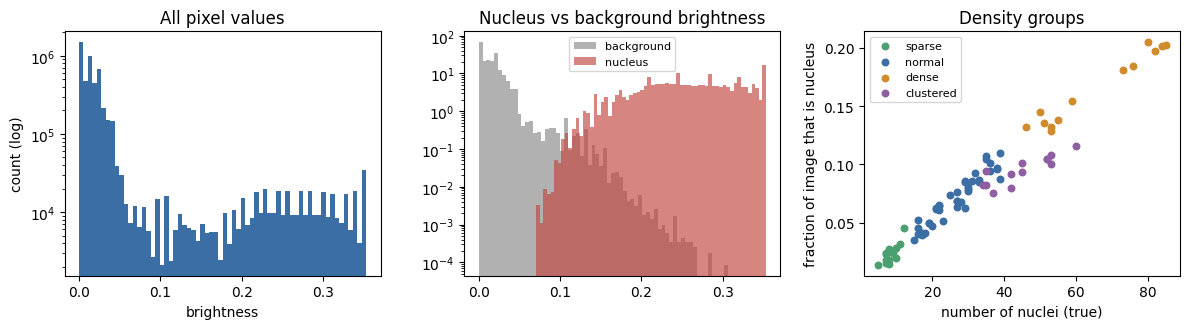

Fraction of all pixels that are nucleus: 0.0809
Average brightness  nucleus=0.2608  background=0.0160


In [4]:
# Gather pixel brightness values across many training images, split into
# "inside a nucleus" (foreground) and "not inside a nucleus" (background),
# using the ground-truth mask to tell them apart.
train_ids = list_ids("train")
all_pixels = np.concatenate([
    load_gray(DATA_DIR / "train" / "images" / f"{i}.png").ravel() for i in train_ids
])

fg_list, bg_list = [], []
for image_id in train_ids[:40]:
    gray = load_gray(DATA_DIR / "train" / "images" / f"{image_id}.png")
    mask = load_mask(DATA_DIR / "train" / "masks" / f"{image_id}.png").astype(bool)
    fg_list.append(gray[mask])
    bg_list.append(gray[~mask])
fg = np.concatenate(fg_list)
bg = np.concatenate(bg_list)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].hist(all_pixels, bins=64, color="#3b6ea5"); ax[0].set_yscale("log")
ax[0].set_title("All pixel values"); ax[0].set_xlabel("brightness"); ax[0].set_ylabel("count (log)")

ax[1].hist(bg, bins=64, alpha=.65, label="background", color="#888", density=True)
ax[1].hist(fg, bins=64, alpha=.65, label="nucleus", color="#c1443c", density=True)
ax[1].set_yscale("log"); ax[1].legend(fontsize=8)
ax[1].set_title("Nucleus vs background brightness")

colors = {"sparse": "#4c9f70", "normal": "#3b6ea5", "dense": "#d18b2c", "clustered": "#8e5ea2"}
for density, color in colors.items():
    subset = meta[(meta.split == "train") & (meta.density == density)]
    ax[2].scatter(subset.n_objects, subset.area_fraction, s=22, label=density, color=color)
ax[2].set_xlabel("number of nuclei (true)"); ax[2].set_ylabel("fraction of image that is nucleus")
ax[2].set_title("Density groups"); ax[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig2_eda_hist.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Fraction of all pixels that are nucleus: {len(fg) / (len(fg) + len(bg)):.4f}")
print(f"Average brightness  nucleus={fg.mean():.4f}  background={bg.mean():.4f}")


### 1.4 Ask a local AI model to describe one image

We ask a local vision model (through Ollama) to look at one picture and
describe it in plain words. We try two prompts:
- a **naive** prompt (just "what do you see?")
- a **structured** prompt that tells the model to only describe what it sees
  (not to give a medical diagnosis), and to answer in a fixed JSON format,
  using "uncertain" if it is not sure about something.

If Ollama is not installed or not running, we skip this and say so clearly.

In [5]:
import urllib.request, urllib.error, base64, re, subprocess, shutil

OLLAMA_URL = "http://localhost:11434/api/generate"
OLLAMA_TAGS_URL = "http://localhost:11434/api/tags"
TEXT_MODEL = "llama3.1:8b"
VISION_MODELS_TO_TRY = ["llama3.2-vision", "llava:7b"]   # try in this order


# Checks if a local Ollama server is running and answering.
def ollama_is_running():
    try:
        urllib.request.urlopen(OLLAMA_TAGS_URL, timeout=3)
        return True
    except Exception:
        return False


# Sends one prompt (and optionally one image) to a local Ollama model.
# Returns (reply_text, source). source is "ollama" if it worked, or
# "offline-backup" if it did not - so we always know where an answer came from.
def call_llm(prompt, image_path=None, model=None, temperature=0.2, timeout=1200, quiet=False):
    model = model or (VISION_MODELS_TO_TRY[0] if image_path else TEXT_MODEL)
    payload = {
        "model": model, "prompt": prompt, "stream": False, "keep_alive": "10m",
        "options": {"temperature": temperature, "num_predict": 500},
    }
    if image_path is not None:
        payload["images"] = [base64.b64encode(Path(image_path).read_bytes()).decode()]
    try:
        request = urllib.request.Request(
            OLLAMA_URL, data=json.dumps(payload).encode(),
            headers={"Content-Type": "application/json"})
        with urllib.request.urlopen(request, timeout=timeout) as response:
            return json.loads(response.read().decode())["response"], "ollama"
    except Exception as exc:
        if not quiet:
            print(f"  (could not reach Ollama: {type(exc).__name__}: {exc})")
        return None, "offline-backup"


# Tries each vision model in turn with a tiny test image, and returns the
# first one that actually replies. Returns None if none of them work.
def find_working_vision_model():
    if not ollama_is_running():
        return None
    probe_path = Path("/tmp/probe.png")
    Image.fromarray((np.random.rand(64, 64) * 255).astype("uint8")).save(probe_path)
    for candidate in VISION_MODELS_TO_TRY:
        text, _ = call_llm("Reply with the word: ok.", image_path=probe_path,
                            model=candidate, timeout=900, quiet=True)
        if text is not None:
            return candidate
    return None


# Finds the last JSON object inside a block of text, even if there is
# extra text or markdown around it.
def extract_json(text):
    if not text:
        return None
    text = re.sub(r"```(?:json)?", "", text)
    best = None
    for match in re.finditer(r"\{", text):
        depth = 0
        for i in range(match.start(), len(text)):
            if text[i] == "{":
                depth += 1
            elif text[i] == "}":
                depth -= 1
                if depth == 0:
                    try:
                        best = json.loads(text[match.start(): i + 1])
                    except json.JSONDecodeError:
                        pass
                    break
    return best


VISION_MODEL = find_working_vision_model()
print("Working vision model found:", VISION_MODEL if VISION_MODEL else "none (Ollama not available here)")


Working vision model found: none (Ollama not available here)


### 1.4b Install and start Ollama (only if it is not already running)

The check above looks for an Ollama server that is *already* running. If none is found, this cell tries to install Ollama, start the server, and download the models this notebook uses. This step needs internet access and takes a few minutes the first time - after that, the models stay downloaded and this cell finishes instantly.

If your computer/session does not allow installing new software (some locked-down Jupyter setups), this cell simply prints a warning and the notebook carries on using the offline backup text, exactly as before.

In [6]:
OLLAMA_MODELS = ["llama3.2-vision", "llava:7b", "llama3.1:8b"]  # vision x2 (first that works), then text


# Runs a shell command with a hard time limit, so a blocked/slow network
# cannot make this cell hang for a long time - it just gives up and moves on.
def run_with_timeout(command, timeout_seconds, use_shell=False):
    try:
        subprocess.run(command, shell=use_shell, timeout=timeout_seconds,
                        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        return True
    except subprocess.TimeoutExpired:
        print(f"  (gave up after {timeout_seconds}s - no response)")
        return False
    except Exception as exc:
        print(f"  ({type(exc).__name__}: {exc})")
        return False


if not ollama_is_running():
    # Step 1: install Ollama if the "ollama" command does not exist yet.
    # A short timeout means a blocked network fails fast instead of hanging.
    if shutil.which("ollama") is None:
        print("Ollama is not installed here - trying to install it now (needs internet access)...")
        run_with_timeout("curl -fsSL --connect-timeout 8 --max-time 120 https://ollama.com/install.sh | sh",
                          timeout_seconds=150, use_shell=True)

    # Step 2: start the Ollama server in the background, then wait for it
    # to answer requests (up to 1 minute).
    if shutil.which("ollama") is not None:
        print("Starting the Ollama server...")
        subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        for _ in range(30):
            if ollama_is_running():
                print("Ollama server is up.")
                break
            time.sleep(2)
        else:
            print("Ollama server did not start in time.")
    else:
        print("Could not install Ollama in this environment - continuing without it. "
              "The rest of the notebook still works, using the offline backup text instead.")

# Step 3: download the models, if the server is now reachable. Already-downloaded
# models are skipped automatically by "ollama pull", so this is safe to re-run.
# Each pull gets a generous but finite time limit (large vision models take a while).
if ollama_is_running():
    print("\nMaking sure the required models are downloaded (skips any already present)...")
    for model in OLLAMA_MODELS:
        print(f"  ollama pull {model}")
        run_with_timeout(["ollama", "pull", model], timeout_seconds=900)
    print("Models ready.")


Ollama is not installed here - trying to install it now (needs internet access)...
Could not install Ollama in this environment - continuing without it. The rest of the notebook still works, using the offline backup text instead.


In [7]:
# Re-run the probe now that Ollama may have just been installed/started/pulled.
VISION_MODEL = find_working_vision_model()
print("Working vision model found:", VISION_MODEL if VISION_MODEL else "none (Ollama still not available here)")


Working vision model found: none (Ollama still not available here)


In [8]:
# The naive prompt: short and open-ended, no rules.
PROMPT_NAIVE = "What do you see in this medical image?"

# The structured prompt: this is the important one for the report.
# It tells the model: describe only what you see, do not diagnose, answer
# in JSON only, using a fixed list of allowed words, and say "uncertain"
# instead of guessing.
PROMPT_STRUCTURED = '''You are helping describe pictures from a microscopy teaching \
dataset. Only describe what you can actually see in the picture. You are not a \
doctor and this is not a diagnosis: do not name a disease, do not guess a medical \
condition, and do not say anything about a patient.

Look at the picture and answer with just one JSON object. Do not write anything \
before or after it, and do not use markdown formatting like triple backticks.

Use this exact structure. Every key is required, and each value must come from \
the word list given for it:
{
  "modality": pick one - ["fluorescence_microscopy","brightfield_microscopy","histology",
                      "radiograph","ct","mri","ultrasound","uncertain"],
  "tissue_type": pick one - ["cell_nuclei","cell_culture","tissue_section","other","uncertain"],
  "notable_features": a list of 2 to 5 short, plain descriptions of only what you see
                      (for example: "bright round shapes on a dark background",
                       "shapes are different sizes", "some shapes are touching"),
  "image_quality": pick one - ["good","adequate","poor","uncertain"],
  "confidence": pick one - ["high","medium","low"]
}

A few rules to follow:
- If you cannot tell something just from the pixels, write "uncertain". That is \
always a fine answer - do not make a guess.
- Do not try to count the objects, since you cannot do this reliably. Do not give any measurements either.
- Only describe things that are actually visible in this picture - nothing else.
'''

print("--- NAIVE PROMPT ---")
print(PROMPT_NAIVE)
print("\n--- STRUCTURED PROMPT ---")
print(PROMPT_STRUCTURED)


--- NAIVE PROMPT ---
What do you see in this medical image?

--- STRUCTURED PROMPT ---
You are helping describe pictures from a microscopy teaching dataset. Only describe what you can actually see in the picture. You are not a doctor and this is not a diagnosis: do not name a disease, do not guess a medical condition, and do not say anything about a patient.

Look at the picture and answer with just one JSON object. Do not write anything before or after it, and do not use markdown formatting like triple backticks.

Use this exact structure. Every key is required, and each value must come from the word list given for it:
{
  "modality": pick one - ["fluorescence_microscopy","brightfield_microscopy","histology",
                      "radiograph","ct","mri","ultrasound","uncertain"],
  "tissue_type": pick one - ["cell_nuclei","cell_culture","tissue_section","other","uncertain"],
  "notable_features": a list of 2 to 5 short, plain descriptions of only what you see
                      (f

In [9]:
REP_IMAGE = DATA_DIR / "train" / "images" / f"{reps['normal']}.png"

naive_reply, structured_reply, repeats = None, None, []

if VISION_MODEL:
    naive_reply, _ = call_llm(PROMPT_NAIVE, image_path=REP_IMAGE, model=VISION_MODEL)
    structured_reply, _ = call_llm(PROMPT_STRUCTURED, image_path=REP_IMAGE, model=VISION_MODEL)
    print("--- NAIVE REPLY ---\n", naive_reply)
    print("\n--- STRUCTURED REPLY ---\n", structured_reply)

    # Ask the same structured question 3 times, to show the answers are not
    # always exactly the same, even though we asked the same question.
    for k in range(3):
        text, _ = call_llm(PROMPT_STRUCTURED, image_path=REP_IMAGE, model=VISION_MODEL, temperature=0.2)
        repeats.append(text)
        print(f"\n--- run {k + 1} ---\n{text}")
    print("\nAll three answers exactly the same:", len(set(repeats)) == 1)
else:
    print("No working vision model here, so this step is skipped.")
    print("To try it yourself: install Ollama, run 'ollama serve', then")
    print("'ollama pull llama3.2-vision' (or 'ollama pull llava:7b' as a backup),")
    print("and re-run this cell.")

# Save everything so it can go in the report.
task1_result = {
    "vision_model": VISION_MODEL,
    "prompt_naive": PROMPT_NAIVE,
    "prompt_structured": PROMPT_STRUCTURED,
    "naive_reply": naive_reply,
    "structured_reply": structured_reply,
    "structured_repeats": repeats,
    "repeats_identical": (len(set(repeats)) == 1) if repeats else None,
}
(OUT_DIR / "task1_vlm.json").write_text(json.dumps(task1_result, indent=2))
print("\nSaved to", OUT_DIR / "task1_vlm.json")


No working vision model here, so this step is skipped.
To try it yourself: install Ollama, run 'ollama serve', then
'ollama pull llama3.2-vision' (or 'ollama pull llava:7b' as a backup),
and re-run this cell.

Saved to out/task1_vlm.json


---
## Task 2 — Classical image processing, then ask the AI to explain the numbers

Here we do NOT use the AI model to look at the image. Instead we:
1. Threshold the image to find bright objects (Otsu's method).
2. Clean up the shape a little (remove tiny specks, close small gaps).
3. Label each separate object and split touching objects apart (watershed).
4. Measure each object (area, shape, brightness) with scikit-image.
5. Give **only the numbers** (not the image) to a local text AI model, and
   ask it to write a short paragraph and a JSON summary.

In [12]:
from scipy import ndimage as ndi
from skimage import measure, morphology
from skimage.feature import peak_local_max
from skimage.filters import threshold_otsu
from skimage.segmentation import watershed
from skimage.color import label2rgb


# Finds bright objects using Otsu's method, then cleans up small mistakes.
def otsu_segment(gray, min_size=30, closing_radius=2):
    threshold = threshold_otsu(gray)
    binary = gray > threshold
    binary = morphology.closing(binary, morphology.disk(closing_radius))   # close tiny gaps
    binary = morphology.remove_small_holes(binary, area_threshold=64)            # fill tiny holes
    binary = morphology.remove_small_objects(binary, min_size=min_size)    # remove tiny specks
    return binary, float(threshold)


# Gives each separate object a number (a "label"). If use_watershed is True,
# touching objects are also split apart using a watershed on the distance map.
def label_objects(binary, use_watershed=True, min_distance=4):
    if not use_watershed:
        return measure.label(binary)
    distance = ndi.distance_transform_edt(binary)
    peaks = peak_local_max(distance, min_distance=min_distance, labels=binary)
    markers = np.zeros(distance.shape, dtype=int)
    for idx, (r, c) in enumerate(peaks, start=1):
        markers[r, c] = idx
    markers = ndi.label(markers > 0)[0]
    return watershed(-distance, markers, mask=binary)


REGION_PROPERTIES = (
    "label", "area", "perimeter", "eccentricity", "solidity", "extent",
    "equivalent_diameter", "major_axis_length", "minor_axis_length",
    "orientation", "mean_intensity", "max_intensity", "min_intensity", "centroid",
)


# Measures every labelled object: size, shape, brightness, etc.
def region_features(labels, gray):
    if labels.max() == 0:
        return pd.DataFrame(columns=list(REGION_PROPERTIES))
    df = pd.DataFrame(measure.regionprops_table(labels, intensity_image=gray, properties=REGION_PROPERTIES))
    df["circularity"] = np.where(df.perimeter > 0, 4 * np.pi * df.area / df.perimeter**2, np.nan)
    df["aspect_ratio"] = np.where(df.minor_axis_length > 0, df.major_axis_length / df.minor_axis_length, np.nan)
    return df


# Counts objects that touch the edge of the image (these are often cut off).
def count_border_objects(df, image_size=IMG_SIZE, margin=2):
    if len(df) == 0:
        return 0
    r, c, radius = df["centroid-0"], df["centroid-1"], df.equivalent_diameter / 2
    touches_edge = ((r - radius < margin) | (c - radius < margin) |
                     (r + radius > image_size - margin) | (c + radius > image_size - margin))
    return int(touches_edge.sum())


# Two simple, image-only quality checks (no AI involved):
# - contrast_score: how much brighter the objects are than the background
# - focus_score: how sharp the image looks (blurry images score lower)
def quality_metrics(gray):
    threshold = threshold_otsu(gray)
    fg, bg = gray[gray > threshold], gray[gray <= threshold]
    contrast = float(fg.mean() - bg.mean()) if fg.size else 0.0
    focus = float(ndi.laplace(gray.astype(np.float64)).var() / (gray.var() + 1e-9))
    return dict(otsu_threshold=round(float(threshold), 4),
                contrast_score=round(contrast, 4), focus_score=round(focus, 4))


ZERO_OBJECT_FIELDS = ("mean_area", "median_area", "min_area", "max_area", "std_area",
                       "mean_equiv_diameter", "mean_eccentricity", "mean_solidity",
                       "mean_circularity", "mean_aspect_ratio", "mean_intensity")


# Turns a segmentation mask into the flat dictionary of numbers we send to
# the AI model. Both the Otsu pipeline (Task 2) and the U-Net pipeline
# (Task 4) use this same function, so their results are directly comparable.
def measure_field(image_id, gray, mask):
    labels = label_objects(mask.astype(bool), use_watershed=True)
    df = region_features(labels, gray)
    m = dict(image_id=image_id, image_size=f"{IMG_SIZE}x{IMG_SIZE}",
             n_objects=int(len(df)), area_fraction=round(float(mask.sum()) / mask.size, 4),
             **quality_metrics(gray))
    if len(df) == 0:
        m.update({k: 0.0 for k in ZERO_OBJECT_FIELDS})
        m["n_border_objects"] = 0
        return m, df
    m.update(dict(
        mean_area=round(float(df.area.mean()), 1), median_area=round(float(df.area.median()), 1),
        min_area=round(float(df.area.min()), 1), max_area=round(float(df.area.max()), 1),
        std_area=round(float(df.area.std(ddof=0)), 1),
        mean_equiv_diameter=round(float(df.equivalent_diameter.mean()), 2),
        mean_eccentricity=round(float(df.eccentricity.mean()), 3),
        mean_solidity=round(float(df.solidity.mean()), 3),
        mean_circularity=round(float(df.circularity.mean()), 3),
        mean_aspect_ratio=round(float(df.aspect_ratio.mean()), 2),
        mean_intensity=round(float(df.mean_intensity.mean()), 3),
        n_border_objects=count_border_objects(df)))
    return m, df


# Same Dice/IoU formula used everywhere in this notebook, so every method
# (Otsu and U-Net) is scored the exact same way.
def dice_iou(pred, gt, eps=1e-7):
    pred, gt = pred.astype(bool), gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    dice = (2 * intersection + eps) / (pred.sum() + gt.sum() + eps)
    iou = (intersection + eps) / (np.logical_or(pred, gt).sum() + eps)
    return float(dice), float(iou)

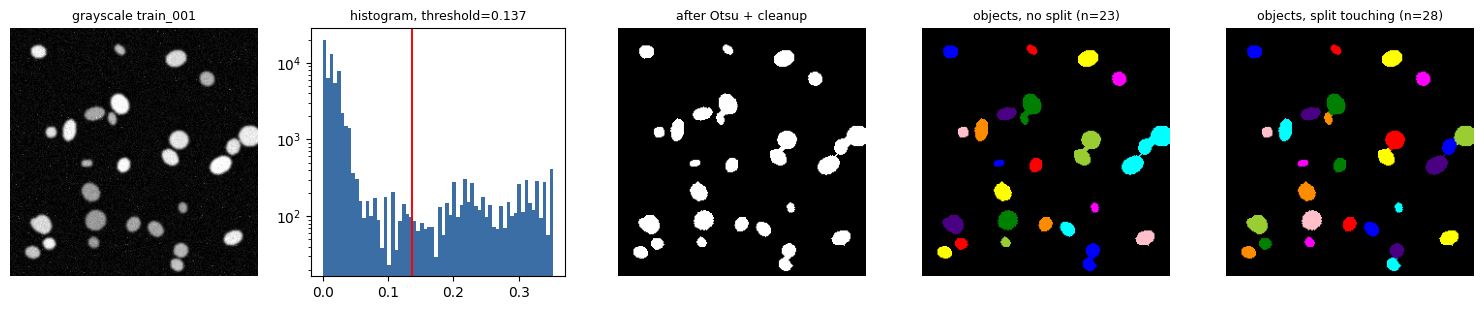

   label   area  eccentricity  solidity  circularity  mean_intensity
0      1   85.0         0.729     0.934        0.983           0.220
1      2  170.0         0.467     0.966        1.018           0.291
2      3  288.0         0.646     0.983        0.996           0.274
3      4  176.0         0.303     0.957        0.958           0.221
4      5  349.0         0.523     0.941        0.842           0.299
5      6  217.0         0.779     0.923        0.836           0.213
6      7   84.0         0.763     0.913        0.915           0.215
7      8  253.0         0.819     0.955        0.851           0.291
true number of objects: 29


In [13]:
# Run the classical pipeline on one example image and show every step.
IID = reps["normal"]
gray = load_gray(DATA_DIR / "train" / "images" / f"{IID}.png")

binary, otsu_threshold = otsu_segment(gray)
labels_plain = label_objects(binary, use_watershed=False)
labels_split = label_objects(binary, use_watershed=True)
feature_table = region_features(labels_split, gray)

fig, ax = plt.subplots(1, 5, figsize=(15, 3.2))
ax[0].imshow(gray, cmap="gray", vmin=0, vmax=np.percentile(gray, 99.9)); ax[0].set_title(f"grayscale {IID}", fontsize=9)
ax[1].hist(gray.ravel(), bins=64, color="#3b6ea5"); ax[1].axvline(otsu_threshold, color="r", lw=1.4)
ax[1].set_yscale("log"); ax[1].set_title(f"histogram, threshold={otsu_threshold:.3f}", fontsize=9)
ax[2].imshow(binary, cmap="gray"); ax[2].set_title("after Otsu + cleanup", fontsize=9)
ax[3].imshow(label2rgb(labels_plain, bg_label=0)); ax[3].set_title(f"objects, no split (n={labels_plain.max()})", fontsize=9)
ax[4].imshow(label2rgb(labels_split, bg_label=0)); ax[4].set_title(f"objects, split touching (n={labels_split.max()})", fontsize=9)
for a in ax:
    if a is not ax[1]:
        a.axis("off")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig3_classical.png", dpi=160, bbox_inches="tight")
plt.show()

feature_table.round(2).to_csv(OUT_DIR / f"features_{IID}.csv", index=False)
print(feature_table[["label", "area", "eccentricity", "solidity", "circularity", "mean_intensity"]].head(8).round(3))
print("true number of objects:", int(meta.loc[meta.image_id == IID, "n_objects"].iloc[0]))


### 2.2 The numbers we send to the AI model

In [14]:
m_otsu, _ = measure_field(IID, gray, binary)
print(json.dumps(m_otsu, indent=2))


{
  "image_id": "train_001",
  "image_size": "256x256",
  "n_objects": 28,
  "area_fraction": 0.0869,
  "otsu_threshold": 0.1372,
  "contrast_score": 0.2453,
  "focus_score": 0.6083,
  "mean_area": 203.5,
  "median_area": 181.5,
  "min_area": 67.0,
  "max_area": 376.0,
  "std_area": 91.8,
  "mean_equiv_diameter": 15.65,
  "mean_eccentricity": 0.538,
  "mean_solidity": 0.946,
  "mean_circularity": 0.932,
  "mean_aspect_ratio": 1.25,
  "mean_intensity": 0.249,
  "n_border_objects": 1
}


### 2.3 Ask the AI to explain the numbers (it never sees the image)

We keep a strict rule here: **every number in the final record comes from
our own measurements, never from the AI model's words.** The AI can only
choose a label from a fixed list (like "sparse"/"moderate"/"dense") and
write the paragraph. If the model's JSON disagrees with a computed number,
we log that disagreement instead of trusting the model.

In [15]:
# The list of allowed words for each field. Keeping this in one place means
# the prompt, the checking code, and the backup answer can never disagree.
ALLOWED_WORDS = {
    "density_class": ["sparse", "moderate", "dense", "uncertain"],
    "shape_regularity": ["regular", "mixed", "irregular", "uncertain"],
    "quality_flag": ["ok", "low_contrast", "blurred", "segmentation_unreliable", "uncertain"],
}

PROMPT_NUMBERS_FIRST = '''You are writing up results for a lab report. You are only \
given a table of numbers that came from a classic image-processing method (an Otsu \
threshold, cleaning up the shapes, labelling each object, then measuring them with \
scikit-image). You have not looked at the actual picture, so do not write as if you had.

Give your answer in two parts, in this order:

PART 1: Write one short paragraph, about 3 to 5 sentences, in everyday English, \
that explains what the numbers below mean. Only use numbers that are actually \
given to you - do not make any number up. Do not give a diagnosis or a medical \
opinion of any kind. Call the objects "segmented objects", nothing more specific than that.

PART 2: Write one JSON object by itself, with nothing written after it:
{
  "n_objects": integer, must match the measurements exactly,
  "density_class": pick one - ["sparse","moderate","dense","uncertain"],
  "shape_regularity": pick one - ["regular","mixed","irregular","uncertain"],
  "quality_flag": pick one - ["ok","low_contrast","blurred","segmentation_unreliable","uncertain"]
}

If the numbers do not clearly support a field, write "uncertain" for it. Do not add any extra keys.

MEASUREMENTS:
{measurements}
'''

PROMPT_HYBRID_RECORD = '''You are the final reporting step of a pipeline that must be \
easy to check and trust. You are given a set of numbers that scikit-image measured \
from a U-Net segmentation mask. You have not seen the actual picture.

Give exactly two parts in your answer.

PART 1: One JSON object by itself, nothing else on those lines:
{
  "image_id": string, must match exactly,
  "n_objects": integer, must match exactly,
  "mean_area": number, must match exactly,
  "density_class": pick one - ["sparse","moderate","dense","uncertain"],
  "quality_flag": pick one - ["ok","low_contrast","blurred","segmentation_unreliable","uncertain"]
}

PART 2: One paragraph, 3 to 4 sentences, written for a technician who will check \
this run. Mention how many objects there are, their usual size and how much that \
size varies, a quick note on their shape, and any quality problem. Only use the \
numbers you were given - do not add a diagnosis, do not guess where the sample \
came from, and do not mention anything that is not in the measurements. If the \
quality flag is anything other than "ok", say clearly that the numbers below \
should be treated as not fully certain yet.

MEASUREMENTS:
{measurements}
'''


# Simple rule-based labels, worked out straight from the numbers. These are
# used two ways: (1) as the backup answer when Ollama is not running, and
# (2) as a "reference answer" to check the AI's own labels against.
def classify_measurements(m):
    n, area_fraction = m["n_objects"], m["area_fraction"]
    if n < 15 and area_fraction < 0.05:
        density = "sparse"
    elif n >= 35 or area_fraction > 0.12:
        density = "dense"
    else:
        density = "moderate"

    solidity, circularity = m.get("mean_solidity", 1.0), m.get("mean_circularity", 1.0)
    if solidity > 0.95 and circularity > 0.85:
        shape = "regular"
    elif solidity < 0.88 or circularity < 0.70:
        shape = "irregular"
    else:
        shape = "mixed"

    if m.get("focus_score", 1) < 0.15:
        quality = "blurred"
    elif m.get("contrast_score", 1) < 0.15:
        quality = "low_contrast"
    elif n == 0 or solidity < 0.80:
        quality = "segmentation_unreliable"
    else:
        quality = "ok"
    return density, shape, quality


# A simple, fixed-template backup answer, used only when Ollama cannot be
# reached, so the notebook still runs from start to end without it.
def offline_backup_reply(m, kind):
    density, shape, quality = classify_measurements(m)
    if m["n_objects"] == 0:
        paragraph = ("The segmentation returned no objects, so no per-object statistics could be "
                     "computed; the field should be re-examined before the measurements are used.")
    else:
        warning = "" if quality == "ok" else (
            f" The quality flag '{quality}' was raised, so these numbers should be "
            "treated as provisional and reviewed before use.")
        lead = f"Image {m['image_id']}: " if kind == "t4" else ""
        paragraph = (
            f"{lead}The segmentation isolated {m['n_objects']} objects covering "
            f"{100 * m['area_fraction']:.1f}% of the {m['image_size']} field, which "
            f"corresponds to a {density} field. Objects have a mean area of "
            f"{m['mean_area']:.0f} pixels (median {m['median_area']:.0f}, range "
            f"{m['min_area']:.0f}-{m['max_area']:.0f}), equivalent to a typical diameter "
            f"of about {m['mean_equiv_diameter']:.0f} pixels. Shape statistics are "
            f"{shape}: mean solidity {m['mean_solidity']:.2f}, mean circularity "
            f"{m['mean_circularity']:.2f} and mean eccentricity {m['mean_eccentricity']:.2f}. "
            f"Mean intensity inside the objects is {m['mean_intensity']:.2f} against a "
            f"background separation of {m['contrast_score']:.2f}.{warning}")
    if kind == "t2":
        record = {"n_objects": int(m["n_objects"]), "density_class": density,
                  "shape_regularity": shape, "quality_flag": quality}
    else:
        record = {"image_id": m["image_id"], "n_objects": int(m["n_objects"]),
                  "mean_area": round(float(m["mean_area"]), 1),
                  "density_class": density, "quality_flag": quality}
    return paragraph + "\n\n" + json.dumps(record)


# Removes the JSON block(s) from a reply so we are left with just the plain
# text paragraph.
def strip_json_blocks(text):
    if not text:
        return ""
    text = re.sub(r"```(?:json)?", "", text)
    kept, depth = [], 0
    for ch in text:
        if ch == "{":
            depth += 1
        if depth == 0:
            kept.append(ch)
        if ch == "}":
            depth = max(0, depth - 1)
    prose = re.sub(r"PART\s*[12]\s*[:\-]?", " ", "".join(kept))
    return re.sub(r"\s+", " ", prose).strip()


# Checks the AI's JSON reply against our computed numbers, and fixes any
# field that is missing, wrong, or not in the allowed word list. Every fix
# made is written down in "corrections" so nothing is changed silently.
def check_and_fix_record(model_record, computed, keys):
    clean, fixes = {}, []
    model_record = model_record or {}
    for key in keys:
        value = model_record.get(key)
        if key in computed:
            if value is None:
                fixes.append(f"{key}: missing -> used computed value")
            elif isinstance(computed[key], (int, float)) and not isinstance(computed[key], bool):
                try:
                    if abs(float(value) - float(computed[key])) > 1e-6:
                        fixes.append(f"{key}: model said {value} -> used computed {computed[key]}")
                except (TypeError, ValueError):
                    fixes.append(f"{key}: model said {value!r} (not a number) -> used computed {computed[key]}")
            elif str(value) != str(computed[key]):
                fixes.append(f"{key}: model said {value!r} -> used computed {computed[key]!r}")
            clean[key] = computed[key]
        elif key in ALLOWED_WORDS:
            if isinstance(value, str) and value.lower() in ALLOWED_WORDS[key]:
                clean[key] = value.lower()
            else:
                fixes.append(f"{key}: {value!r} is not an allowed word -> used 'uncertain'")
                clean[key] = "uncertain"
        else:
            clean[key] = value if isinstance(value, list) else ([] if value is None else [str(value)])
    extra = [k for k in model_record if k not in keys]
    if extra:
        fixes.append(f"removed extra keys the model added: {extra}")
    return clean, fixes


# Runs one full "measurements -> checked JSON + paragraph" step.
# kind is "t2" (Task 2) or "t4" (Task 4) - this picks which fields are expected.
def run_llm_step(prompt_template, measurements, kind, temperature=0.2):
    prompt = prompt_template.replace("{measurements}", json.dumps(measurements, indent=2, default=float))
    text, source = call_llm(prompt, temperature=temperature)
    if text is None:
        text, source = offline_backup_reply(measurements, kind), "offline-backup"

    raw_record = extract_json(text)
    ref_density, ref_shape, ref_quality = classify_measurements(measurements)

    if kind == "t2":
        keys = ["n_objects", "density_class", "shape_regularity", "quality_flag"]
        computed = {"n_objects": int(measurements["n_objects"]), "quality_flag": ref_quality}
    else:
        keys = ["image_id", "n_objects", "mean_area", "density_class", "quality_flag"]
        computed = {"image_id": measurements["image_id"], "n_objects": int(measurements["n_objects"]),
                    "mean_area": round(float(measurements["mean_area"]), 1), "quality_flag": ref_quality}

    record, corrections = check_and_fix_record(raw_record, computed, keys)
    if raw_record and str(raw_record.get("density_class", "")).lower() != ref_density:
        corrections.append(
            f"density_class: model said {raw_record.get('density_class')!r}, "
            f"rule-based check says {ref_density!r} (kept the model's word - this is "
            "a judgement call, not a copied number)")

    return dict(prompt=prompt, raw_text=text, record=record, corrections=corrections,
                narrative=strip_json_blocks(text), source=source,
                reference_labels=dict(density_class=ref_density, shape_regularity=ref_shape, quality_flag=ref_quality))


In [16]:
t2 = run_llm_step(PROMPT_NUMBERS_FIRST, m_otsu, kind="t2")
print("answer came from:", t2["source"])
print("\nparagraph:", t2["narrative"])
print("\nJSON record:", json.dumps(t2["record"], indent=2))
print("\ncorrections made:", t2["corrections"])
print("\ntrue number of objects:", int(meta.loc[meta.image_id == IID, "n_objects"].iloc[0]),
      "| true density:", meta.loc[meta.image_id == IID, "density"].iloc[0])

(OUT_DIR / "task2_result.json").write_text(json.dumps(
    {"measurements": m_otsu, "prompt": t2["prompt"], "narrative": t2["narrative"],
     "record": t2["record"], "corrections": t2["corrections"], "source": t2["source"]},
    indent=2, default=float))
print("\nSaved to", OUT_DIR / "task2_result.json")


  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
answer came from: offline-backup

paragraph: The segmentation isolated 28 objects covering 8.7% of the 256x256 field, which corresponds to a moderate field. Objects have a mean area of 204 pixels (median 182, range 67-376), equivalent to a typical diameter of about 16 pixels. Shape statistics are mixed: mean solidity 0.95, mean circularity 0.93 and mean eccentricity 0.54. Mean intensity inside the objects is 0.25 against a background separation of 0.25.

JSON record: {
  "n_objects": 28,
  "density_class": "moderate",
  "shape_regularity": "mixed",
  "quality_flag": "ok"
}

corrections made: []

true number of objects: 29 | true density: normal

Saved to out/task2_result.json


---
## Task 3 — Train a small U-Net to segment the nuclei

A U-Net is a neural network shaped like a "U": it shrinks the image down
(encoder), then builds it back up to full size (decoder), with shortcut
connections between matching levels so fine detail is not lost. We train a
small version of it (few layers, few channels) since our dataset is small.

We try three ways of scoring how wrong the model is (the "loss function"):
plain BCE, soft Dice, and BCE+Dice together - and keep whichever gives the
best validation Dice score.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
print("Using device:", DEVICE)


# Two 3x3 convolutions in a row - the basic building block of a U-Net.
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


# A small U-Net: goes down 3 levels, then back up 3 levels, with skip
# connections carrying detail across from the down path to the up path.
class SmallUNet(nn.Module):
    def __init__(self, base=8, depth=3, in_ch=1):
        super().__init__()
        channels = [base * 2**i for i in range(depth + 1)]
        self.depth = depth

        self.encoder = nn.ModuleList()
        c = in_ch
        for ch in channels[:-1]:
            self.encoder.append(DoubleConv(c, ch))
            c = ch
        self.bottleneck = DoubleConv(c, channels[-1])
        self.decoder = nn.ModuleList([DoubleConv(channels[i + 1] + channels[i], channels[i]) for i in range(depth)])
        self.out_conv = nn.Conv2d(channels[0], 1, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skips = []
        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for i in range(self.depth - 1, -1, -1):
            x = F.interpolate(x, scale_factor=2, mode="nearest")
            x = torch.cat([x, skips[i]], dim=1)
            x = self.decoder[i](x)
        return self.out_conv(x)   # raw scores, not yet turned into probabilities


# Feeds the model random 128x128 crops with random flips/rotations during
# training (this is called "data augmentation" - it helps a small model
# learn more from a small dataset). For evaluation we use crop=None, which
# gives back the full 256x256 image instead.
class NucleiDataset(Dataset):
    def __init__(self, images, masks, crop=None, augment=False, seed=0):
        self.images, self.masks, self.crop, self.augment = images, masks, crop, augment
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x, y = self.images[idx], self.masks[idx]
        if self.crop:
            r0 = int(self.rng.integers(0, x.shape[0] - self.crop + 1))
            c0 = int(self.rng.integers(0, x.shape[1] - self.crop + 1))
            x = x[r0:r0 + self.crop, c0:c0 + self.crop]
            y = y[r0:r0 + self.crop, c0:c0 + self.crop]
        if self.augment:
            k = int(self.rng.integers(0, 4))
            x, y = np.rot90(x, k), np.rot90(y, k)
            if self.rng.random() < 0.5:
                x, y = x[:, ::-1], y[:, ::-1]
            if self.rng.random() < 0.5:
                x, y = x[::-1], y[::-1]
        x_t = torch.from_numpy(np.ascontiguousarray(x))[None].float()
        y_t = torch.from_numpy(np.ascontiguousarray(y))[None].float()
        return x_t, y_t


# Soft Dice loss: 1 minus the (soft) overlap between prediction and truth.
def dice_loss(logits, target, eps=1.0):
    probs = torch.sigmoid(logits)
    intersection = (probs * target).sum()
    return 1 - (2 * intersection + eps) / (probs.sum() + target.sum() + eps)

bce_loss_fn = nn.BCEWithLogitsLoss()

def make_loss(kind):
    if kind == "bce":
        return lambda logits, y: bce_loss_fn(logits, y)
    if kind == "dice":
        return lambda logits, y: dice_loss(logits, y)
    return lambda logits, y: bce_loss_fn(logits, y) + dice_loss(logits, y)   # "bce_dice"


# Runs the model on a full image set (no cropping) and returns per-image
# Dice, per-image IoU, and the raw probability maps.
@torch.no_grad()
def evaluate(model, images, masks, threshold=0.5, batch_size=4):
    model.eval()
    probs = []
    for i in range(0, len(images), batch_size):
        xb = torch.from_numpy(images[i:i + batch_size])[:, None].float().to(DEVICE)
        probs.append(torch.sigmoid(model(xb)).cpu().numpy())
    probs = np.concatenate(probs)[:, 0]
    dices, ious = zip(*[dice_iou(probs[k] > threshold, masks[k] > 0.5) for k in range(len(images))])
    return np.array(dices), np.array(ious), probs


# Trains one U-Net from scratch and returns the model from the epoch with
# the best validation Dice score (not necessarily the very last epoch).
def train_unet(train_loader, val_images, val_masks, loss_kind="bce_dice", epochs=30, lr=1e-3, seed=SEED, verbose=True):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = SmallUNet().to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = make_loss(loss_kind)

    history = []
    best_dice, best_state, best_epoch = -1.0, None, -1

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, n_batches = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimiser.step()
            total_loss += loss.item()
            n_batches += 1

        val_dice, val_iou, _ = evaluate(model, val_images, val_masks)
        model.eval()
        with torch.no_grad():
            val_losses = [
                criterion(model(torch.from_numpy(val_images[i:i + 4])[:, None].float().to(DEVICE)),
                          torch.from_numpy(val_masks[i:i + 4])[:, None].float().to(DEVICE)).item()
                for i in range(0, len(val_images), 4)
            ]
        val_loss = float(np.mean(val_losses))

        history.append(dict(epoch=epoch, train_loss=total_loss / n_batches, val_loss=val_loss,
                            val_dice=val_dice.mean(), val_iou=val_iou.mean()))
        if val_dice.mean() > best_dice:
            best_dice = val_dice.mean()
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
        if verbose:
            print(f"[{loss_kind}] epoch {epoch:02d}  train {total_loss / n_batches:.4f}  "
                  f"val {val_loss:.4f}  dice {val_dice.mean():.4f}  iou {val_iou.mean():.4f}")

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch


Using device: cpu


In [20]:
tr_ids, Xtr, Ytr = load_split("train")
va_ids, Xva, Yva = load_split("val")
te_ids, Xte, Yte = load_split("test")
print("train / val / test image counts:", len(tr_ids), len(va_ids), len(te_ids))

train_dataset = NucleiDataset(Xtr, Ytr, crop=TRAIN_CROP, augment=True, seed=1)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)


train / val / test image counts: 80 20 12


In [21]:
EPOCHS = 25   # kept modest so this runs in a reasonable time; raise it for a longer, more thorough run

ablation = {}
trained_models = {}
for loss_kind in ["bce", "dice", "bce_dice"]:
    t0 = time.time()
    model, history, best_epoch = train_unet(train_loader, Xva, Yva, loss_kind=loss_kind, epochs=EPOCHS, verbose=False)
    val_dice, val_iou, _ = evaluate(model, Xva, Yva)
    history.to_csv(OUT_DIR / f"history_{loss_kind}.csv", index=False)
    ablation[loss_kind] = dict(
        val_dice=float(val_dice.mean()), val_iou=float(val_iou.mean()),
        val_dice_std=float(val_dice.std()), val_dice_min=float(val_dice.min()),
        best_epoch=int(best_epoch), minutes=round((time.time() - t0) / 60, 2))
    trained_models[loss_kind] = model
    print(loss_kind, ablation[loss_kind])

ablation_df = pd.DataFrame(ablation).T
print(ablation_df.round(4))

best_loss_kind = ablation_df.val_dice.idxmax()
unet = trained_models[best_loss_kind]
print("Best loss function:", best_loss_kind)
torch.save(unet.state_dict(), OUT_DIR / "unet_best.pt")


bce {'val_dice': 0.9920240604393171, 'val_iou': 0.9841920384210274, 'val_dice_std': 0.003011097039274412, 'val_dice_min': 0.9869387755107372, 'best_epoch': 24, 'minutes': 2.47}
dice {'val_dice': 0.988540527055612, 'val_iou': 0.9773713623218241, 'val_dice_std': 0.003984631017830537, 'val_dice_min': 0.9813311688319265, 'best_epoch': 24, 'minutes': 2.43}
bce_dice {'val_dice': 0.9908007070558271, 'val_iou': 0.9817927437946888, 'val_dice_std': 0.003485808487840471, 'val_dice_min': 0.9848189957187692, 'best_epoch': 25, 'minutes': 2.4}
          val_dice  val_iou  val_dice_std  val_dice_min  best_epoch  minutes
bce         0.9920   0.9842        0.0030        0.9869        24.0     2.47
dice        0.9885   0.9774        0.0040        0.9813        24.0     2.43
bce_dice    0.9908   0.9818        0.0035        0.9848        25.0     2.40
Best loss function: bce


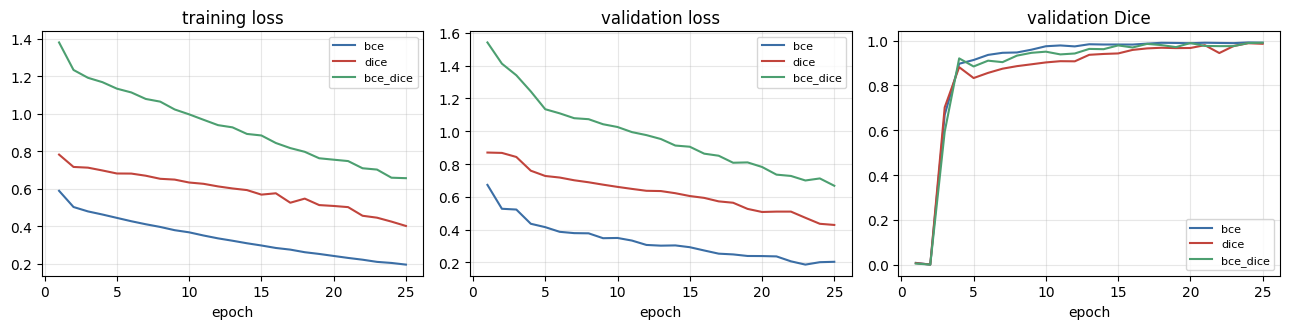

In [22]:
OUT_DIR = Path('/content/out') # Ensure OUT_DIR is an absolute path to where history files were saved.

# Plot how training went for all three loss functions.
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
colors = {"bce": "#3b6ea5", "dice": "#c1443c", "bce_dice": "#4c9f70"}
for loss_kind, color in colors.items():
    h = pd.read_csv(OUT_DIR / f"history_{loss_kind}.csv")
    ax[0].plot(h.epoch, h.train_loss, color=color, label=loss_kind)
    ax[1].plot(h.epoch, h.val_loss, color=color, label=loss_kind)
    ax[2].plot(h.epoch, h.val_dice, color=color, label=loss_kind)
ax[0].set_title("training loss"); ax[1].set_title("validation loss"); ax[2].set_title("validation Dice")
for a in ax:
    a.set_xlabel("epoch"); a.legend(fontsize=8); a.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig4_curves.png", dpi=160, bbox_inches="tight")
plt.show()

### 3.1 Validation Dice/IoU, and how the old Otsu method compares

In [23]:
val_dice, val_iou, val_probs = evaluate(unet, Xva, Yva)
val_df = pd.DataFrame(dict(image_id=va_ids, dice=val_dice, iou=val_iou)).merge(
    meta[["image_id", "density", "n_objects"]], on="image_id")
val_df.to_csv(OUT_DIR / "unet_val_per_image.csv", index=False)
print(f"VALIDATION  average Dice {val_dice.mean():.4f} (+/- {val_dice.std():.4f})   average IoU {val_iou.mean():.4f}")
print(val_df.groupby("density")[["dice", "iou"]].agg(["mean", "min"]).round(4))
print("\nWorst 3 validation images:")
print(val_df.sort_values("dice").head(3).round(4))

# Score the plain Otsu method on the same images, using the same Dice/IoU
# function, so the two methods are compared fairly.
otsu_rows = []
for split in ["val", "test"]:
    for image_id in list_ids(split):
        g = load_gray(DATA_DIR / split / "images" / f"{image_id}.png")
        gt = load_mask(DATA_DIR / split / "masks" / f"{image_id}.png")
        b, _ = otsu_segment(g)
        d, i_ = dice_iou(b, gt)
        otsu_rows.append(dict(image_id=image_id, split=split, dice=d, iou=i_))
otsu_df = pd.DataFrame(otsu_rows)
otsu_df.to_csv(OUT_DIR / "otsu_baseline.csv", index=False)
print("\nOtsu method scores:")
print(otsu_df.groupby("split")[["dice", "iou"]].mean().round(4))


VALIDATION  average Dice 0.9920 (+/- 0.0030)   average IoU 0.9842
             dice             iou        
             mean     min    mean     min
density                                  
clustered  0.9938  0.9930  0.9877  0.9860
dense      0.9923  0.9893  0.9848  0.9788
normal     0.9926  0.9878  0.9854  0.9760
sparse     0.9889  0.9869  0.9781  0.9742

Worst 3 validation images:
   image_id    dice     iou density  n_objects
18  val_018  0.9869  0.9742  sparse          7
12  val_012  0.9871  0.9746  sparse          8
1   val_001  0.9878  0.9760  normal         31

Otsu method scores:
         dice     iou
split                
test   0.9749  0.9511
val    0.9742  0.9497


### 3.2 Picture check: input, true mask, and prediction, side by side

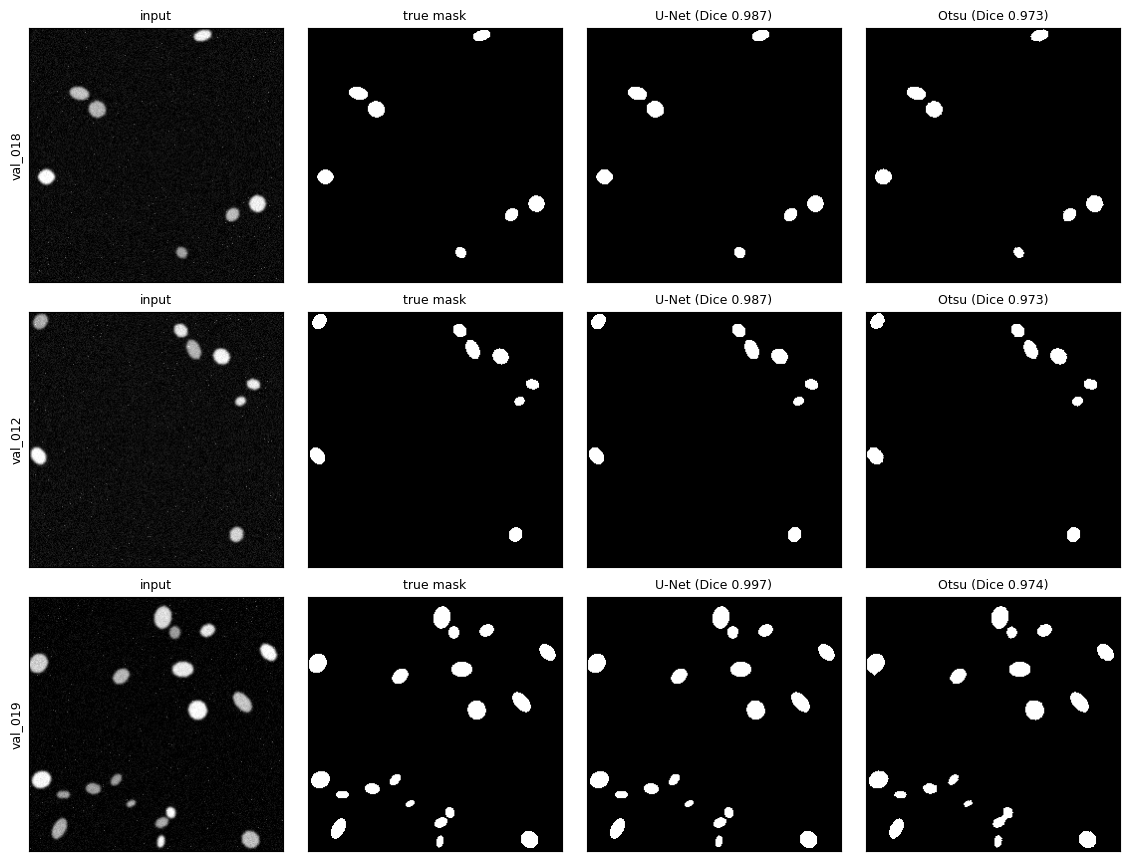

In [24]:
show_ids = list(val_df.sort_values("dice").image_id[:2]) + [val_df.sort_values("dice").image_id.iloc[-1]]
fig, ax = plt.subplots(len(show_ids), 4, figsize=(11.5, 2.9 * len(show_ids)))
for r, image_id in enumerate(show_ids):
    k = va_ids.index(image_id)
    g, gt, pred_prob = Xva[k], Yva[k], val_probs[k]
    pred = pred_prob > 0.5
    otsu_mask, _ = otsu_segment(g)
    dice_u, _ = dice_iou(pred, gt)
    dice_o, _ = dice_iou(otsu_mask, gt)
    panels = [g, gt, pred, otsu_mask]
    titles = ["input", "true mask", f"U-Net (Dice {dice_u:.3f})", f"Otsu (Dice {dice_o:.3f})"]
    for c, (img, title) in enumerate(zip(panels, titles)):
        ax[r, c].imshow(img, cmap="gray", vmin=0, vmax=(np.percentile(g, 99.9) if c == 0 else 1))
        ax[r, c].set_title(title, fontsize=9); ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
    ax[r, 0].set_ylabel(image_id, fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig5_unet_panels.png", dpi=160, bbox_inches="tight")
plt.show()


---
## Task 4 — Full pipeline on the unseen test images

For every test image: run the U-Net -> measure the objects -> ask the AI
for a checked JSON record and a paragraph -> collect everything into one
table and save it as a CSV file.

In [25]:
# Runs the U-Net on one image and turns the output into a plain 0/1 mask.
def segment_with_unet(model, gray, threshold=0.5):
    model.eval()
    with torch.no_grad():
        x = torch.from_numpy(gray)[None, None].float().to(DEVICE)
        prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()
    return prob > threshold


# Runs the whole Task 4 chain on one image and returns the record + text.
def run_pipeline_on_image(image_id, gray, gt_mask, model):
    pred_mask = segment_with_unet(model, gray)
    dice, iou = dice_iou(pred_mask, gt_mask)

    measurements, _ = measure_field(image_id, gray, pred_mask)
    result = run_llm_step(PROMPT_HYBRID_RECORD, measurements, kind="t4")

    record = dict(result["record"])
    record.update(
        dice_vs_gt=round(dice, 4), iou_vs_gt=round(iou, 4),
        area_fraction=measurements["area_fraction"], mean_solidity=measurements["mean_solidity"],
        mean_eccentricity=measurements["mean_eccentricity"], contrast_score=measurements["contrast_score"],
        focus_score=measurements["focus_score"], n_corrections=len(result["corrections"]),
        llm_source=result["source"])
    return record, result["narrative"]


records, narratives = [], {}
for image_id in te_ids:
    idx = te_ids.index(image_id)
    record, narrative = run_pipeline_on_image(image_id, Xte[idx], Yte[idx], unet)
    true_row = meta.loc[meta.image_id == image_id].iloc[0]
    record.update(n_objects_true=int(true_row.n_objects), true_density=str(true_row.density))
    records.append(record)
    narratives[image_id] = narrative

pipeline_df = pd.DataFrame(records)
pipeline_df.to_csv(OUT_DIR / "pipeline_records.csv", index=False)
(OUT_DIR / "pipeline_narratives.json").write_text(json.dumps(narratives, indent=2))
print(pipeline_df)
print("\nSaved table to", OUT_DIR / "pipeline_records.csv")


  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] C

In [26]:
print("mean test Dice :", round(pipeline_df.dice_vs_gt.mean(), 4))
print("mean test IoU  :", round(pipeline_df.iou_vs_gt.mean(), 4))
print("count error (average, ignoring +/-):", round((pipeline_df.n_objects - pipeline_df.n_objects_true).abs().mean(), 2))
print("count bias (average, with +/-)     :", round((pipeline_df.n_objects - pipeline_df.n_objects_true).mean(), 2))
print("quality flags seen:", pipeline_df.quality_flag.value_counts().to_dict())
print("total corrections made across all test images:", int(pipeline_df.n_corrections.sum()))

example_id = te_ids[0]
print("\nEXAMPLE RECORD\n", json.dumps(pipeline_df.iloc[0].to_dict(), indent=2, default=str))
print("\nEXAMPLE PARAGRAPH\n", narratives[example_id])


mean test Dice : 0.9908
mean test IoU  : 0.9818
count error (average, ignoring +/-): 5.75
count bias (average, with +/-)     : -5.75
quality flags seen: {'ok': 12}
total corrections made across all test images: 0

EXAMPLE RECORD
 {
  "image_id": "test_000",
  "n_objects": 8,
  "mean_area": 193.2,
  "density_class": "sparse",
  "quality_flag": "ok",
  "dice_vs_gt": 0.9942,
  "iou_vs_gt": 0.9884,
  "area_fraction": 0.0236,
  "mean_solidity": 0.97,
  "mean_eccentricity": 0.636,
  "contrast_score": 0.2085,
  "focus_score": 2.3247,
  "n_corrections": 0,
  "llm_source": "offline-backup",
  "n_objects_true": 8,
  "true_density": "sparse"
}

EXAMPLE PARAGRAPH
 Image test_000: The segmentation isolated 8 objects covering 2.4% of the 256x256 field, which corresponds to a sparse field. Objects have a mean area of 193 pixels (median 181, range 59-428), equivalent to a typical diameter of about 15 pixels. Shape statistics are regular: mean solidity 0.97, mean circularity 0.98 and mean eccentricity 

---
## Extra credit — Robustness check

We take one test image and make two damaged copies of it (blurred, and low
contrast — these copies come already made in `test_corrupted/`). Then we
run the same steps on all three versions and compare, to see: at which
step does the damage first become obvious in the numbers?

In [27]:
BASE_ID = "test_000"
paths = {
    "clean": DATA_DIR / "test" / "images" / f"{BASE_ID}.png",
    "blur": DATA_DIR / "test_corrupted" / "images" / f"{BASE_ID}_blur.png",
    "lowcontrast": DATA_DIR / "test_corrupted" / "images" / f"{BASE_ID}_lowcontrast.png",
}
gt_mask = load_mask(DATA_DIR / "test" / "masks" / f"{BASE_ID}.png")

rob_rows, rob_narratives, rob_panels = [], {}, {}
for variant_name, path in paths.items():
    if not path.exists():
        continue
    gray = load_gray(path)
    otsu_mask, _ = otsu_segment(gray)
    unet_mask = segment_with_unet(unet, gray)

    unet_m, _ = measure_field(f"{BASE_ID}_{variant_name}", gray, unet_mask)
    otsu_m, _ = measure_field(f"{BASE_ID}_{variant_name}", gray, otsu_mask)
    result = run_llm_step(PROMPT_HYBRID_RECORD, unet_m, kind="t4")

    dice_unet, _ = dice_iou(unet_mask, gt_mask)
    dice_otsu, _ = dice_iou(otsu_mask, gt_mask)

    rob_rows.append(dict(
        variant=variant_name, **quality_metrics(gray),
        unet_dice=round(dice_unet, 4), otsu_dice=round(dice_otsu, 4),
        unet_n=unet_m["n_objects"], otsu_n=otsu_m["n_objects"],
        unet_mean_area=unet_m["mean_area"], mean_solidity=unet_m["mean_solidity"],
        density_class=result["record"]["density_class"], quality_flag=result["record"]["quality_flag"]))
    rob_narratives[f"{BASE_ID}_{variant_name}"] = result["narrative"]
    rob_panels[variant_name] = (gray, otsu_mask, unet_mask)

rob_df = pd.DataFrame(rob_rows)
rob_df.to_csv(OUT_DIR / "robustness.csv", index=False)
print(rob_df)
for variant_name in paths:
    key = f"{BASE_ID}_{variant_name}"
    if key in rob_narratives:
        print(f"\n[{key}]\n{rob_narratives[key]}")


  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
  (could not reach Ollama: URLError: <urlopen error [Errno 111] Connection refused>)
       variant  otsu_threshold  contrast_score  focus_score  unet_dice  \
0        clean          0.1137          0.2085       2.3247     0.9942   
1         blur          0.0553          0.0868       0.0172     0.7792   
2  lowcontrast          0.4392          0.0296       2.8968     0.0457   

   otsu_dice  unet_n  otsu_n  unet_mean_area  mean_solidity density_class  \
0     0.9804       8       8           193.2          0.970        sparse   
1     0.7022       7       8           200.7          0.947        sparse   
2     0.9566       1       9         65536.0          1.000         dense   

   quality_flag  
0            ok  
1       blurred  
2  low_contrast  

[test_000_clean]
Image test_000_clean: The segmentation isolated 8

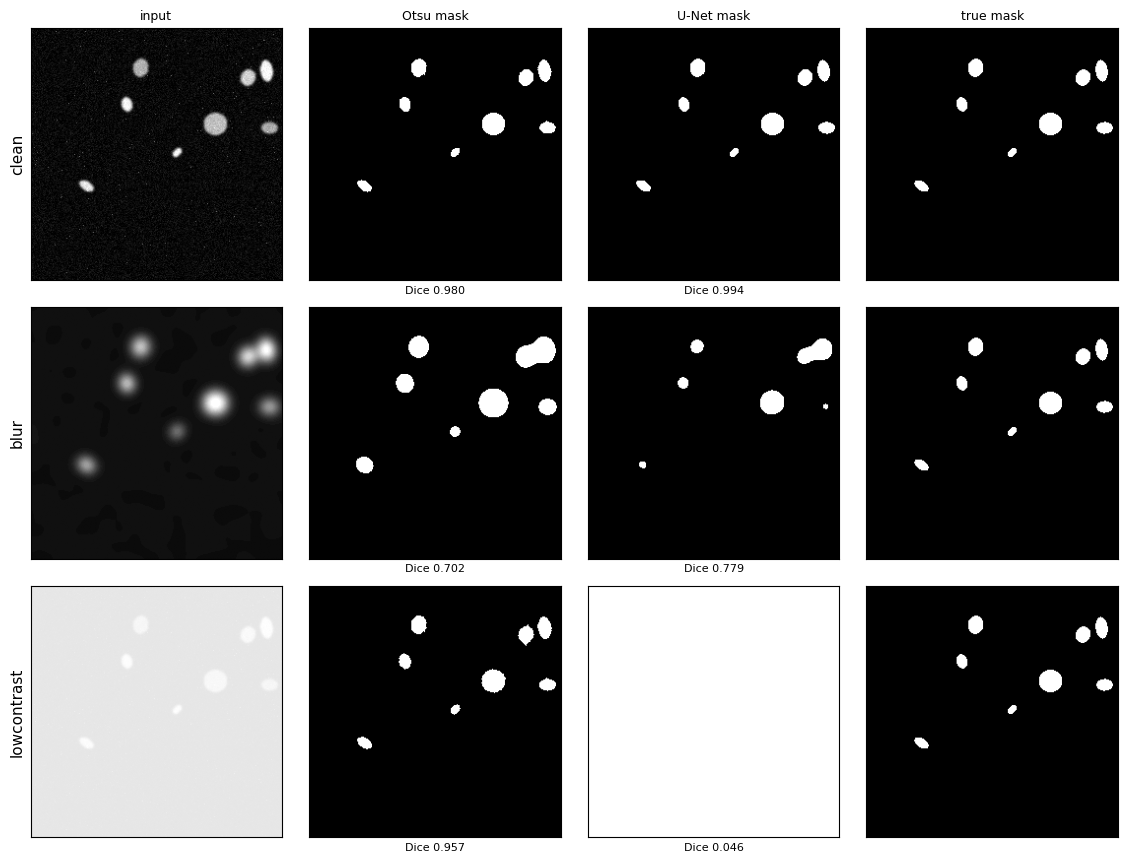

In [28]:
fig, ax = plt.subplots(len(rob_panels), 4, figsize=(11.5, 2.9 * len(rob_panels)))
for r, (variant_name, (g, otsu_mask, unet_mask)) in enumerate(rob_panels.items()):
    row = rob_df[rob_df.variant == variant_name].iloc[0]
    panels = [g, otsu_mask, unet_mask, gt_mask]
    titles = ["input", "Otsu mask", "U-Net mask", "true mask"]
    xlabels = ["", f"Dice {row.otsu_dice:.3f}", f"Dice {row.unet_dice:.3f}", ""]
    for c, (img, title, xl) in enumerate(zip(panels, titles, xlabels)):
        ax[r, c].imshow(img, cmap="gray", vmin=0, vmax=(float(np.percentile(g, 99.9)) if c == 0 else 1))
        if r == 0:
            ax[r, c].set_title(title, fontsize=9)
        ax[r, c].set_xlabel(xl, fontsize=8); ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
    ax[r, 0].set_ylabel(variant_name, fontsize=11)
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig6_robustness.png", dpi=155, bbox_inches="tight")
plt.show()


---
## Summary numbers (for the report)

In [29]:
summary = dict(
    dataset=dict(n_images=int(len(meta)), splits=meta.split.value_counts().to_dict(),
                 n_objects_range=[int(meta.n_objects.min()), int(meta.n_objects.max())],
                 fg_pixel_fraction=round(float(len(fg) / (len(fg) + len(bg))), 4)),
    otsu=dict(val_dice=round(float(otsu_df[otsu_df.split == "val"].dice.mean()), 4),
              val_iou=round(float(otsu_df[otsu_df.split == "val"].iou.mean()), 4),
              test_dice=round(float(otsu_df[otsu_df.split == "test"].dice.mean()), 4)),
    unet=dict(params=int(sum(p.numel() for p in unet.parameters())), best_loss=best_loss_kind,
              val_dice=round(float(val_dice.mean()), 4), val_iou=round(float(val_iou.mean()), 4),
              val_dice_std=round(float(val_dice.std()), 4),
              test_dice=round(float(pipeline_df.dice_vs_gt.mean()), 4),
              test_iou=round(float(pipeline_df.iou_vs_gt.mean()), 4)),
    ablation=ablation,
    pipeline=dict(count_mae=round(float((pipeline_df.n_objects - pipeline_df.n_objects_true).abs().mean()), 2),
                  count_bias=round(float((pipeline_df.n_objects - pipeline_df.n_objects_true).mean()), 2),
                  quality_flags=pipeline_df.quality_flag.value_counts().to_dict(),
                  corrections=int(pipeline_df.n_corrections.sum())),
    robustness=rob_df.to_dict("records"),
    llm_source=("ollama" if VISION_MODEL else "offline-backup"))

(OUT_DIR / "report_numbers.json").write_text(json.dumps(summary, indent=2, default=float))
print(json.dumps(summary, indent=2, default=float))


{
  "dataset": {
    "n_images": 112,
    "splits": {
      "train": 80,
      "val": 20,
      "test": 12
    },
    "n_objects_range": [
      5,
      85
    ],
    "fg_pixel_fraction": 0.0809
  },
  "otsu": {
    "val_dice": 0.9742,
    "val_iou": 0.9497,
    "test_dice": 0.9749
  },
  "unet": {
    "params": 122673,
    "best_loss": "bce",
    "val_dice": 0.992,
    "val_iou": 0.9842,
    "val_dice_std": 0.003,
    "test_dice": 0.9908,
    "test_iou": 0.9818
  },
  "ablation": {
    "bce": {
      "val_dice": 0.9920240604393171,
      "val_iou": 0.9841920384210274,
      "val_dice_std": 0.003011097039274412,
      "val_dice_min": 0.9869387755107372,
      "best_epoch": 24,
      "minutes": 2.47
    },
    "dice": {
      "val_dice": 0.988540527055612,
      "val_iou": 0.9773713623218241,
      "val_dice_std": 0.003984631017830537,
      "val_dice_min": 0.9813311688319265,
      "best_epoch": 24,
      "minutes": 2.43
    },
    "bce_dice": {
      "val_dice": 0.9908007070558271,
 